In [ ]:
!pip install qiskit pylatexenc

In [ ]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit import Parameter, Instruction, Gate
from qiskit.circuit.library import *
import numpy as np
import matplotlib.pyplot as plt


Boolean Logic Gates

# Boolean Logic Gate and Circuit Representations in Qiskit

These classes implement classical Boolean logic using reversible quantum circuits.

Used in:

- reversible computing
- Grover oracles
- arithmetic circuits
- Boolean function synthesis

---

# Important Difference

Qiskit provides two forms:

| Type | Meaning |
|---|---|
| Gate Representation | Single reusable gate object |
| QuantumCircuit Representation | Full circuit implementation |

---

# Main Concept

## Gate Representation

Acts like a reusable instruction.

Example:

```python
AndGate(...)
```

Can be appended into circuits.

---

## QuantumCircuit Representation

Creates a complete circuit structure.

Example:

```python
AND(...)
```

Contains internal decomposition and wiring.

---

# Analogy

| Representation | Analogy |
|---|---|
| Gate | packaged operation |
| Circuit | full implementation |

---

# AND Operation

## Logical Rule

$$
1 \land 1 = 1
$$

Otherwise:

$$
0
$$

---

# AndGate

## Gate Representation

Represents logical AND as a reusable gate.

```python
AndGate(num_variable_qubits)
```

Acts as a single instruction object.

---

# AND

## QuantumCircuit Representation

Complete circuit implementing AND logic.

Usually decomposed using:

- CCX gates
- ancilla qubits
- reversible logic

```python
AND(num_variable_qubits)
```

---

# Difference

| AndGate | AND |
|---|---|
| abstract gate object | full decomposed circuit |
| reusable instruction | explicit implementation |
| compact representation | circuit structure |

---

# OR Operation

## Logical Rule

$$
1 \lor 0 = 1
$$

$$
0 \lor 0 = 0
$$

---

# OrGate

## Gate Representation

Reusable OR logic gate.

```python
OrGate(num_variable_qubits)
```

---

# OR

## QuantumCircuit Representation

Full circuit implementing OR logic.

Often built using:

- De Morgan transformations
- X gates
- CCX gates

```python
OR(num_variable_qubits)
```

---

# XOR Operation

## Exclusive OR

Rule:

$$
1 \oplus 1 = 0
$$

$$
1 \oplus 0 = 1
$$

---

# BitwiseXorGate

## Gate Representation

Applies XOR with integer bitmask.

Example:

```python
BitwiseXorGate(5)
```

Useful for reversible arithmetic.

---

# XOR

## QuantumCircuit Representation

Complete XOR circuit implementation.

Usually built using:

$$
CX
$$

operations.

```python
XOR(amount)
```

---

# Inner Product Operation

Computes binary inner product over:

$$
F_2
$$

where arithmetic uses modulo 2.

---

# Inner Product Formula

For binary vectors:

$$
a=(a_1,a_2,...,a_n)
$$

$$
b=(b_1,b_2,...,b_n)
$$

Inner product:

$$
a\cdot b
=
a_1b_1 \oplus a_2b_2 \oplus ... \oplus a_nb_n
$$

---

# InnerProductGate

## Gate Representation

Reusable inner-product gate.

Acts as single instruction object.

```python
InnerProductGate(num_qubits)
```

---

# InnerProduct

## QuantumCircuit Representation

Complete circuit implementing inner product computation.

Usually built from:

- CX gates
- AND logic
- XOR accumulation

```python
InnerProduct(num_qubits)
```

---

# Important Concept

These operations must be:

- reversible
- unitary

because quantum circuits cannot lose information.

So classical logic is implemented differently than normal classical hardware.

---

# Reversible Logic Example

Classical AND:

```text
1 AND 1 = 1
```

loses information.

Quantum version stores outputs without destroying inputs.

---

# Why Two Versions Exist

---

# Gate Representation

Useful when:

- appending reusable operations
- circuit composition
- abstract instruction handling

Example:

```python
qc.append(AndGate(3), qubits)
```

---

# QuantumCircuit Representation

Useful when:

- viewing decompositions
- studying implementations
- transpilation analysis

Example:

```python
and_circuit = AND(3)
```

---

# Summary Table

| Gate Representation | Circuit Representation | Purpose |
|---|---|---|
| AndGate | AND | logical AND |
| OrGate | OR | logical OR |
| BitwiseXorGate | XOR | bitwise XOR |
| InnerProductGate | InnerProduct | binary inner product |

---

# Core Difference

## Gate Representation

Represents operation as:

$$
\text{single reusable instruction}
$$

---

## Circuit Representation

Represents operation as:

$$
\text{full decomposed quantum circuit}
$$

with explicit gate implementation.

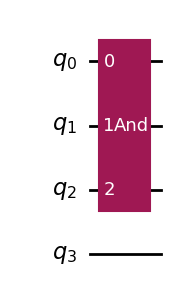

In [ ]:
andgate = AndGate(num_variable_qubits=2)
# if given 2 will take 3 cause 1 qubit need to be there for results
qc = QuantumCircuit(4)

qc.compose(andgate).draw('mpl')

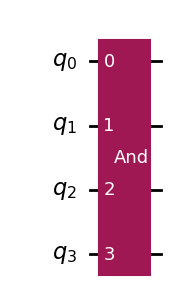

In [ ]:
andgate = AndGate(num_variable_qubits=3)
# if given 2 will take 3 cause 1 qubit need to be there for results
qc = QuantumCircuit(4)
qc.compose(andgate).draw('mpl')

/tmp/ipykernel_3671/3433127280.py:1: DeprecationWarning: The class ``qiskit.circuit.library.boolean_logic.quantum_and.AND`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use qiskit.circuit.library.AndGate instead.
  AND(3).draw('mpl')


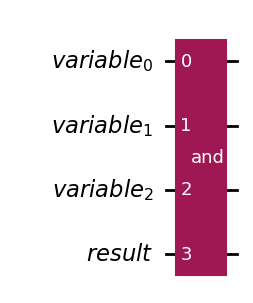

In [ ]:

AND(3).draw('mpl')

BASIS CHANGE GATES

# Basis Change Gates in Quantum Computing

---

# Definition

A basis change gate transforms a qubit from one basis representation to another basis.

These gates change how the quantum state is represented.

---

# Computational Basis

Standard basis states:

$$
|0\rangle =
\begin{bmatrix}
1 \\
0
\end{bmatrix}
$$

$$
|1\rangle =
\begin{bmatrix}
0 \\
1
\end{bmatrix}
$$

This is also called:

$$
\text{Z-basis}
$$

---

# Hadamard Gate

The most important basis change gate.

Matrix:

$$
H =
\frac{1}{\sqrt2}
\begin{bmatrix}
1 & 1 \\
1 & -1
\end{bmatrix}
$$

---

# Hadamard Transformations

$$
H|0\rangle = |+\rangle
$$

$$
H|1\rangle = |-\rangle
$$

Where:

$$
|+\rangle =
\frac{|0\rangle+|1\rangle}{\sqrt2}
$$

$$
|-\rangle =
\frac{|0\rangle-|1\rangle}{\sqrt2}
$$

---

# Basis Conversion

Hadamard changes:

$$
Z\text{-basis} \leftrightarrow X\text{-basis}
$$

---

# Why It Is Called Basis Change

The quantum state is represented using different coordinate systems.

Like rotating axes in geometry.

---

# Common Bases

| Basis | States |
|---|---|
| Z-basis | \(|0\rangle, |1\rangle\) |
| X-basis | \(|+\rangle, |-\rangle\) |
| Y-basis | phase-based states |

---

# Measuring in X Basis

Quantum hardware normally measures in Z-basis.

To measure in X-basis:

1. Apply Hadamard
2. Measure normally

Example:

```python
qc.h(0)
qc.measure(0,0)
```

---

# Y-Basis Measurement

Using:

$$
HS^\dagger
$$

can convert between:

$$
Y\text{-basis} \leftrightarrow Z\text{-basis}
$$

---

# Bloch Sphere Interpretation

Basis change gates rotate coordinate axes on the Bloch sphere.

---

# Important Basis Change Gates

| Gate | Basis Change |
|---|---|
| H | Z ↔ X |
| S + H | Z ↔ Y |
| RX/RY/RZ | rotated bases |
| QFT | computational ↔ Fourier basis |

---

# Why Basis Changes Matter

Used in:

- quantum algorithms
- interference
- quantum Fourier transform
- phase estimation
- entanglement
- measurement protocols

---

# Core Idea

Basis change gates transform quantum states between different coordinate systems (bases) used to represent and measure qubits.

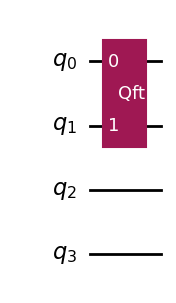

In [ ]:
# Gate Representation

# QFTGate : Quantum Fourier Transform Gate.

qc.compose(QFTGate(2)).draw()



/tmp/ipykernel_3671/83694543.py:5: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  QFT(3).draw('mpl')


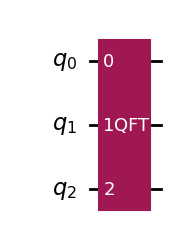

In [ ]:
# Quantum Circuit Representation

# QFT : Quantum Fourier Transform Circuit.

QFT(3).draw('mpl')

Arithmatic Gates

# Adder Gates in Qiskit

Adder gates perform reversible binary arithmetic using qubit registers.

Used in:

- quantum arithmetic
- Shor’s algorithm
- modular arithmetic
- reversible computing

---

# Gate Representation vs QuantumCircuit Representation

| Type | Meaning |
|---|---|
| Gate Representation | Reusable arithmetic gate object |
| QuantumCircuit Representation | Full decomposed arithmetic circuit |

---

# Gate Representation

These behave like reusable gate instructions.

---

# ModularAdderGate

## Modular Addition Gate

Computes:

$$
(a+b)\bmod N
$$

for two quantum registers.

---

## Example

If:

$$
N=4
$$

then:

$$
3+2=5
$$

becomes:

$$
5 \bmod 4 = 1
$$

---

## Used In

- Shor’s algorithm
- modular arithmetic
- cryptographic quantum algorithms

```python
ModularAdderGate(num_state_qubits)
```

---

# HalfAdderGate

## Half Adder Gate

Adds two binary inputs.

Outputs:

- sum bit
- carry-out bit

---

## Sum Formula

$$
a \oplus b
$$

---

## Carry Formula

$$
a \land b
$$

---

## Truth Table

| a | b | Sum | Carry |
|---|---|---|---|
| 0 | 0 | 0 | 0 |
| 0 | 1 | 1 | 0 |
| 1 | 0 | 1 | 0 |
| 1 | 1 | 0 | 1 |

---

## Important

No carry-in bit exists.

```python
HalfAdderGate(num_state_qubits)
```

---

# FullAdderGate

## Full Adder Gate

Adds:

- two input bits
- carry-in bit

Outputs:

- sum bit
- carry-out bit

---

## Sum Formula

$$
a \oplus b \oplus c_{in}
$$

---

## Carry-Out Formula

$$
ab + ac_{in} + bc_{in}
$$

---

## Important

Supports chained multi-bit addition.

```python
FullAdderGate(num_state_qubits)
```

---

# QuantumCircuit Representation

These are full arithmetic circuit implementations.

---

# DraperQFTAdder

## QFT-Based Adder

Uses:

$$
QFT
$$

(Quantum Fourier Transform)

to perform addition.

---

## Main Process

1. Apply QFT
2. Add phases
3. Apply inverse QFT

Addition becomes phase rotations in Fourier space.

---

## Features

- elegant mathematical design
- fewer carry operations
- sensitive to noise

```python
DraperQFTAdder(num_state_qubits)
```

---

# CDKMRippleCarryAdder

## Ripple-Carry Adder

Carry bits propagate sequentially:

```text
carry → next carry → next carry
```

Named after:

- Cuccaro
- Draper
- Kutin
- Moulton

---

## Features

- hardware-friendly
- simple implementation
- deeper circuits

```python
CDKMRippleCarryAdder(num_state_qubits)
```

---

# VBERippleCarryAdder

## Vedral-Barenco-Ekert Ripple Carry Adder

One of the earliest reversible quantum adders.

Uses gates such as:

- CCX
- CX

to implement reversible arithmetic.

---

## Features

- foundational adder design
- reversible logic based
- larger gate count

```python
VBERippleCarryAdder(num_state_qubits)
```

---

# Difference Between Half and Full Adder

| Feature | Half Adder | Full Adder |
|---|---|---|
| Carry-in | No | Yes |
| Carry-out | Yes | Yes |

---

# Difference Between Adder Circuits

| Adder | Method |
|---|---|
| DraperQFTAdder | Fourier-space addition |
| CDKMRippleCarryAdder | Ripple carry propagation |
| VBERippleCarryAdder | Reversible carry logic |

---

# Core Idea

Quantum adder gates implement reversible binary and modular arithmetic using qubit registers and reversible logic circuits.

**Gate Representation**

**ModularAdderGate** : Compute the sum modulo
 of two n-sized qubit registers.

**HalfAdderGate**: Compute the sum of two equally-sized qubit registers, including a carry-out bit.

**FullAdderGate** : Compute the sum of two n-sized qubit registers, including carry-in and -out bits.
QuantumCircuit Representation

**DraperQFTAdder** : A circuit that uses QFT to perform in-place addition on two qubit registers.

**CDKMRippleCarryAdder** : A ripple-carry circuit to perform in-place addition on two qubit registers.

**VBERippleCarryAdder** : The VBE ripple carry adder .

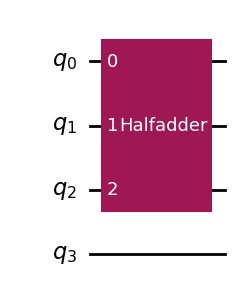

In [ ]:
qc.compose(HalfAdderGate(1)).draw('mpl')

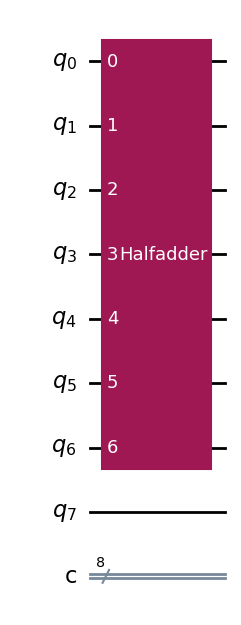

In [ ]:
qc = QuantumCircuit(8,8)

qc.compose(HalfAdderGate(3)).draw('mpl')

# Multipliers in Qiskit

Multiplier circuits perform reversible multiplication using quantum registers.

Used in:

- quantum arithmetic
- Shor’s algorithm
- quantum algorithms
- reversible computing

---

# Gate Representation vs QuantumCircuit Representation

| Type | Meaning |
|---|---|
| Gate Representation | Reusable multiplier gate |
| QuantumCircuit Representation | Full multiplier circuit implementation |

---

# Gate Representation

---

# MultiplierGate

## Multiplication Gate

Computes the product of two equally-sized quantum registers.

General operation:

$$
a \times b
$$

Result is stored in a separate output register.

---

## Important

Multiplication is implemented reversibly.

Inputs are preserved.

---

## Example

If:

$$
a=3,\quad b=2
$$

then:

$$
3\times2=6
$$

Output register stores:

$$
6
$$

---

## Used In

- quantum arithmetic
- modular multiplication
- cryptographic algorithms

```python
MultiplierGate(num_state_qubits)
```

---

# QuantumCircuit Representation

These are full multiplication circuit implementations.

---

# HRSCumulativeMultiplier

## HRS Cumulative Multiplier

Out-of-place multiplication circuit.

Stores multiplication result in a separate register.

---

## Main Idea

Uses cumulative addition operations to compute product.

Conceptually similar to classical multiplication:

```text
repeated shifted additions
```

---

## Features

- reversible multiplication
- preserves input registers
- uses additional output register

```python
HRSCumulativeMultiplier(num_state_qubits)
```

---

# RGQFTMultiplier

## QFT-Based Multiplier

Uses:

$$
QFT
$$

(Quantum Fourier Transform)

to perform multiplication.

---

## Main Idea

Arithmetic operations become phase operations in Fourier space.

Process:

1. Apply QFT
2. Encode multiplication using phases
3. Apply inverse QFT

---

## Features

- Fourier-space arithmetic
- elegant mathematical structure
- many rotation gates

```python
RGQFTMultiplier(num_state_qubits)
```

---

# Important Concept

Quantum multiplication must be:

- reversible
- unitary

Inputs cannot be destroyed.

So multiplication usually uses:

- ancilla qubits
- output registers
- reversible addition circuits

---

# Out-of-Place Computation

The product is stored in a separate register.

Example:

$$
|a,b,0\rangle
\rightarrow
|a,b,a\times b\rangle
$$

Inputs remain unchanged.

---

# Difference Between Multipliers

| Multiplier | Method |
|---|---|
| HRSCumulativeMultiplier | repeated cumulative additions |
| RGQFTMultiplier | Fourier-space multiplication |

---

# Summary Table

| Component | Purpose |
|---|---|
| MultiplierGate | Reversible multiplication gate |
| HRSCumulativeMultiplier | Addition-based multiplier |
| RGQFTMultiplier | QFT-based multiplier |

---

# Core Idea

Quantum multipliers implement reversible multiplication of qubit registers while preserving input information.

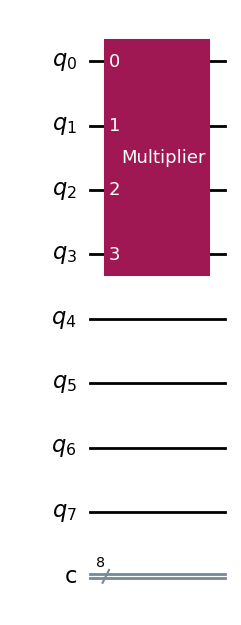

In [ ]:
qc.compose(MultiplierGate(1)).draw('mpl')

# Amplitude Functions in Qiskit

Amplitude functions modify quantum state amplitudes using mathematical functions.

Used in:

- quantum finance
- amplitude estimation
- optimization
- quantum machine learning

---

# Gate Representation vs QuantumCircuit Representation

| Type | Meaning |
|---|---|
| Gate Representation | Reusable amplitude-function gate |
| QuantumCircuit Representation | Full amplitude-function circuit |

---

# Main Idea

These circuits encode mathematical functions into quantum amplitudes.

General linear function:

$$
f(x)=\text{slope}\times x+\text{offset}
$$

---

# LinearAmplitudeFunctionGate

## Gate Representation

Implements a linear or piecewise-linear function on quantum amplitudes.

General form:

$$
f(x)=mx+b
$$

Where:

- \(m\) = slope
- \(b\) = offset

---

# Domain and Image

Function maps:

$$
[a,b]
\rightarrow
[c,d]
$$

Where:

| Term | Meaning |
|---|---|
| Domain | allowed input interval |
| Image | output interval |

---

# Example

Suppose:

$$
f(x)=2x+1
$$

Then:

| x | f(x) |
|---|---|
| 0 | 1 |
| 1 | 3 |
| 2 | 5 |

---

# Piecewise Linear Functions

Different linear equations can apply in different intervals.

Example:

$$
f(x)=
\begin{cases}
x & x<2 \\
2x+1 & x\ge2
\end{cases}
$$

---

# Purpose

Encodes functions into amplitudes for:

- probability estimation
- payoff functions
- quantum finance algorithms

```python
LinearAmplitudeFunctionGate(...)
```

---

# LinearAmplitudeFunction

## QuantumCircuit Representation

Full circuit implementation of amplitude function encoding.

Implements the same linear or piecewise-linear transformation using explicit circuit decomposition.

---

# Features

- circuit-level implementation
- decomposed arithmetic operations
- amplitude encoding

```python
LinearAmplitudeFunction(...)
```

---

# Important Concept

Quantum amplitudes behave like probability amplitudes.

Example state:

$$
|\psi\rangle
=
a|0\rangle+b|1\rangle
$$

These circuits modify amplitudes according to mathematical functions.

---

# Why Useful

Amplitude functions are important in:

| Area | Use |
|---|---|
| Quantum Finance | option pricing |
| Amplitude Estimation | probability estimation |
| Optimization | objective functions |
| Quantum ML | encoding nonlinear functions |

---

# Difference Between Gate and Circuit Representation

| Gate Representation | Circuit Representation |
|---|---|
| reusable instruction object | full decomposed circuit |
| compact abstraction | explicit implementation |
| appendable into circuits | detailed circuit structure |

---

# Summary Table

| Component | Purpose |
|---|---|
| LinearAmplitudeFunctionGate | Reusable linear amplitude-function gate |
| LinearAmplitudeFunction | Full amplitude-function circuit |

---

# Core Idea

Amplitude-function circuits encode mathematical functions into quantum amplitudes using reversible quantum operations.

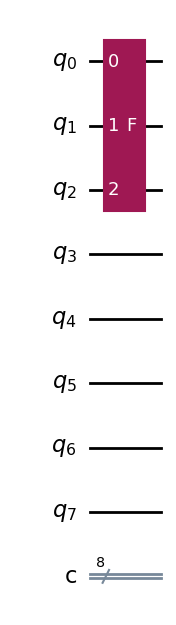

In [ ]:
LAFG = LinearAmplitudeFunctionGate(num_state_qubits=2, slope=2, offset=0, domain=[0,1], image=[0,1,2,3])

qc.compose(LAFG).draw('mpl')

# Functional Pauli Rotations in Qiskit

Functional Pauli rotations apply quantum rotations whose rotation angles are controlled by mathematical functions.

Used in:

- quantum finance
- amplitude estimation
- quantum machine learning
- optimization
- function approximation

---

# Main Idea

Normal rotation gate:

$$
R_X(\theta)
$$

uses a fixed angle:

$$
\theta
$$

Functional Pauli rotations instead use:

$$
\theta=f(x)
$$

where:

- \(x\) = encoded quantum value
- \(f(x)\) = mathematical function

---

# General Concept

Instead of:

```text
fixed rotation
```

these circuits perform:

```text
function-controlled rotation
```

---

# Pauli Rotation Types

Rotations may occur around:

| Rotation | Pauli Axis |
|---|---|
| RX | X-axis |
| RY | Y-axis |
| RZ | Z-axis |

---

# Gate Representation vs QuantumCircuit Representation

| Type | Meaning |
|---|---|
| Gate Representation | reusable gate object |
| QuantumCircuit Representation | full decomposed circuit |

---

# FunctionalPauliRotations

## Base Class

Base framework for all functional Pauli rotation circuits.

Provides common structure for:

- linear rotations
- polynomial rotations
- piecewise functions

```python
FunctionalPauliRotations
```

---

# LinearPauliRotationsGate

## Linear Function Controlled Rotations

Rotation angle depends linearly on input:

$$
f(x)=ax+b
$$

Rotation form:

$$
R_X(f(x))
$$

or:

$$
R_Y(f(x))
$$

or:

$$
R_Z(f(x))
$$

---

## Example

If:

$$
f(x)=2x+1
$$

then rotation angle becomes:

$$
\theta=2x+1
$$

---

## Purpose

Encodes simple linear relationships into amplitudes.

```python
LinearPauliRotationsGate(...)
```

---

# LinearPauliRotations

## Circuit Representation

Full decomposed circuit implementing linear Pauli rotations.

```python
LinearPauliRotations(...)
```

---

# PolynomialPauliRotationsGate

## Polynomial-Controlled Rotations

Rotation angle defined by polynomial:

$$
f(x)=a_0+a_1x+a_2x^2+\cdots
$$

---

## Example

$$
f(x)=x^2+2x+1
$$

Rotation becomes:

$$
R_Y(x^2+2x+1)
$$

---

## Purpose

Encodes nonlinear mathematical behavior.

```python
PolynomialPauliRotationsGate(...)
```

---

# PolynomialPauliRotations

## Circuit Representation

Full polynomial rotation circuit implementation.

```python
PolynomialPauliRotations(...)
```

---

# PiecewiseLinearPauliRotationsGate

## Piecewise Linear Rotations

Different linear equations apply in different intervals.

---

## Example

$$
f(x)=
\begin{cases}
x & x<1 \\
2x+1 & x\ge1
\end{cases}
$$

---

## Purpose

Approximates more complex functions using multiple linear segments.

```python
PiecewiseLinearPauliRotationsGate(...)
```

---

# PiecewiseLinearPauliRotations

## Circuit Representation

Full piecewise-linear rotation circuit.

```python
PiecewiseLinearPauliRotations(...)
```

---

# PiecewisePolynomialPauliRotationsGate

## Piecewise Polynomial Rotations

Different polynomial equations apply in different intervals.

---

## Example

$$
f(x)=
\begin{cases}
x^2 & x<1 \\
2x^2+1 & x\ge1
\end{cases}
$$

---

## Purpose

Represents highly flexible nonlinear functions.

```python
PiecewisePolynomialPauliRotationsGate(...)
```

---

# PiecewisePolynomialPauliRotations

## Circuit Representation

Full piecewise-polynomial rotation circuit.

```python
PiecewisePolynomialPauliRotations(...)
```

---

# PiecewiseChebyshevGate

## Chebyshev Function Approximation

Approximates functions using Chebyshev polynomials.

---

# Chebyshev Polynomial Idea

Complex functions are approximated using polynomial series:

$$
f(x)\approx \sum a_nT_n(x)
$$

where:

$$
T_n(x)
$$

are Chebyshev polynomials.

---

## Why Chebyshev?

Chebyshev approximations are:

- numerically stable
- efficient
- highly accurate

---

## Purpose

Approximate difficult nonlinear functions efficiently.

```python
PiecewiseChebyshevGate(...)
```

---

# PiecewiseChebyshev

## Circuit Representation

Full Chebyshev approximation circuit.

```python
PiecewiseChebyshev(...)
```

---

# Important Concept

These circuits do NOT directly compute classical numbers.

Instead they:

- encode functions into rotation angles
- modify amplitudes
- control probability distributions

---

# Why Functional Rotations Matter

Used heavily in:

| Area | Use |
|---|---|
| Quantum Finance | payoff functions |
| Amplitude Estimation | probability encoding |
| Optimization | objective functions |
| Quantum ML | nonlinear mappings |

---

# Difference Between Function Types

| Type | Function Form |
|---|---|
| Linear | \(ax+b\) |
| Polynomial | \(a_0+a_1x+a_2x^2+\cdots\) |
| Piecewise Linear | multiple linear regions |
| Piecewise Polynomial | multiple polynomial regions |
| Chebyshev | polynomial approximation series |

---

# Difference Between Gate and Circuit Representation

| Gate Representation | Circuit Representation |
|---|---|
| reusable instruction | full decomposed circuit |
| abstract operation | explicit implementation |
| compact object | detailed gate structure |

---

# Summary Table

| Component | Purpose |
|---|---|
| FunctionalPauliRotations | base framework |
| LinearPauliRotationsGate | linear-controlled rotations |
| PolynomialPauliRotationsGate | polynomial rotations |
| PiecewiseLinearPauliRotationsGate | segmented linear rotations |
| PiecewisePolynomialPauliRotationsGate | segmented polynomial rotations |
| PiecewiseChebyshevGate | Chebyshev approximation |

---

# Core Idea

Functional Pauli rotations encode mathematical functions into quantum rotation angles, allowing quantum circuits to represent complex numerical relationships and probability transformations.

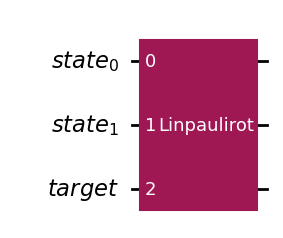

In [ ]:
# Definitions from z2EWieYOsdv6 to make this cell self-contained
slope = 0.5
offset = 0.2
num_state_qubits = 2
num_target_qubits = 1

# Corrected LinearPauliRotations instantiation
# The original error in cell z2EWieYOsdv6 was due to incorrect argument order/passing.
# The LinearPauliRotations constructor expects num_state_qubits, slope, offset positionally,
# and num_target_qubits and basis as keyword arguments or in a different order than provided.
# Correcting to pass num_target_qubits and basis as keyword arguments, and using 'ry' for Y-axis basis.
lpr_cirkit = LinearPauliRotations(num_state_qubits, slope, offset, basis='Y')

lpr_cirkit.draw('mpl')

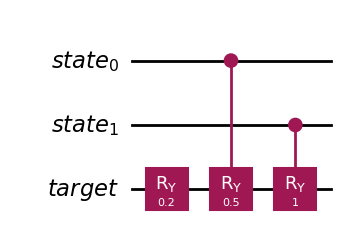

In [ ]:
lpr_cirkit.decompose().draw('mpl')

In [ ]:
qc = QuantumCircuit(num_state_qubits + num_target_qubits)

qc.h(range(num_state_qubits))
qc.append(lpr_cirkit, range(num_state_qubits + num_target_qubits))

print(qc.draw())

     ┌───┐┌─────────┐
q_0: ┤ H ├┤0        ├
     ├───┤│         │
q_1: ┤ H ├┤1 LinRot ├
     └───┘│         │
q_2: ─────┤2        ├
          └─────────┘
